In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_behavior.csv')



In [15]:
print("Average, Median, and Mode of PurchaseAmount")
mean_pa = df['PurchaseAmount'].mean()
median_pa = df['PurchaseAmount'].median()
mode_pa = df['PurchaseAmount'].mode()[0]
print(f"Mean: {mean_pa:.2f}")
print(f"Median: {median_pa:.2f}")
print(f"Mode: {mode_pa:.2f}\n")



Average, Median, and Mode of PurchaseAmount
Mean: 1003.95
Median: 998.08
Mode: 0.00



Outliers in the PurchaseAmount data
Number of outliers found: 15


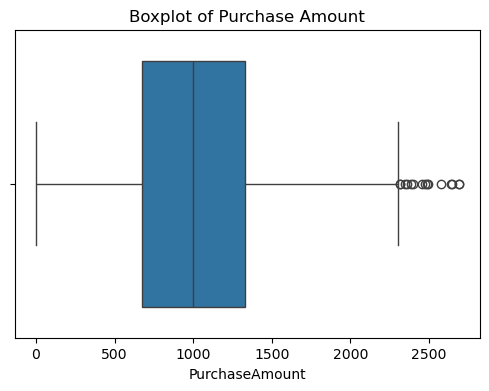

In [16]:
print("Outliers in the PurchaseAmount data")
Q1 = df['PurchaseAmount'].quantile(0.25)
Q3 = df['PurchaseAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['PurchaseAmount'] < lower_bound) | (df['PurchaseAmount'] > upper_bound)]
print(f"Number of outliers found: {len(outliers)}")
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['PurchaseAmount'])
plt.title("Boxplot of Purchase Amount")
plt.show()

In [17]:
print("\nSkewness or Kurtosis in PurchaseAmount")
skewness = df['PurchaseAmount'].skew()
kurtosis = df['PurchaseAmount'].kurt()
print(f"Skewness: {skewness:.3f} (Values > 0 indicate right-skew, < 0 indicate left-skew)")
print(f"Kurtosis: {kurtosis:.3f} (Values > 3 indicate heavier tails than normal)\n")


Skewness or Kurtosis in PurchaseAmount
Skewness: 0.106 (Values > 0 indicate right-skew, < 0 indicate left-skew)
Kurtosis: -0.262 (Values > 3 indicate heavier tails than normal)



In [18]:
print("Significant difference in spending (Male vs. Female)")
male_spend = df[df['Gender'].str.lower() == 'male']['PurchaseAmount']
female_spend = df[df['Gender'].str.lower() == 'female']['PurchaseAmount']

t_stat, p_val = stats.ttest_ind(male_spend, female_spend, equal_var=False) # Welch's t-test
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")
if p_val < 0.05:
    print("Conclusion: There is a significant difference in spending between genders.\n")
else:
    print("Conclusion: No significant difference in spending between genders.\n")

Significant difference in spending (Male vs. Female)
T-statistic: nan, P-value: nan
Conclusion: No significant difference in spending between genders.



In [19]:
print("Relationship between ProductCategory and customer churn")
contingency_table = pd.crosstab(df['ProductCategory'], df['Churn'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi2: {chi2:.3f}, P-value: {p_val_chi:.4f}")
if p_val_chi < 0.05:
    print("Conclusion: There is a significant relationship between ProductCategory and Churn.\n")
else:
    print("Conclusion: No significant relationship between ProductCategory and Churn.\n")

Relationship between ProductCategory and customer churn
Chi2: 0.396, P-value: 0.8204
Conclusion: No significant relationship between ProductCategory and Churn.



In [20]:
print("PurchaseAmount varying across different regions")
regions = df['Region'].unique()
region_data = [df[df['Region'] == region]['PurchaseAmount'] for region in regions]

f_stat, p_val_anova = stats.f_oneway(*region_data)
print(f"F-statistic: {f_stat:.3f}, P-value: {p_val_anova:.4f}")
if p_val_anova < 0.05:
    print("Conclusion: Spending varies significantly across different regions.\n")
else:
    print("Conclusion: No significant variance in spending across regions.\n")

PurchaseAmount varying across different regions
F-statistic: nan, P-value: nan
Conclusion: No significant variance in spending across regions.



In [21]:
print("Email campaign (A vs B) performance")
campaign_means = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
print(campaign_means)
best_campaign = campaign_means.idxmax()
print(f"Campaign {best_campaign} performed better on average.\n")

Email campaign (A vs B) performance
CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64
Campaign A performed better on average.



Normality of PurchaseAmount distribution
Shapiro-Wilk Statistic: nan, P-value: nan
Conclusion: PurchaseAmount follows a normal distribution (fail to reject null).



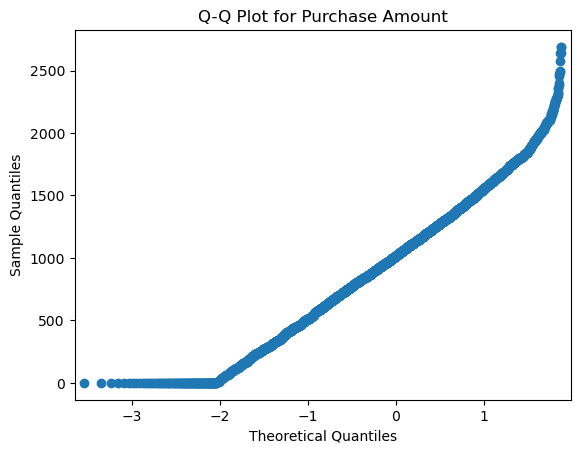

In [22]:
print("Normality of PurchaseAmount distribution")
stat, p_val_shapiro = stats.shapiro(df['PurchaseAmount'])
print(f"Shapiro-Wilk Statistic: {stat:.3f}, P-value: {p_val_shapiro:.4f}")
if p_val_shapiro < 0.05:
    print("Conclusion: PurchaseAmount does NOT follow a normal distribution (reject null hypothesis).\n")
else:
    print("Conclusion: PurchaseAmount follows a normal distribution (fail to reject null).\n")
    
sm.qqplot(df['PurchaseAmount'], line='s')
plt.title("Q-Q Plot for Purchase Amount")
plt.show()

In [23]:
print("Insights from the Central Limit Theorem (CLT)")
print("""
Insight: Even if 'PurchaseAmount' itself is heavily skewed and not normally distributed 
(which is common in financial data), the Central Limit Theorem states that if we pull repeated 
random samples of a sufficient size (usually n >= 30) from the dataset, the distribution of 
the *sample means* will be approximately normal. This allows us to safely use parametric 
tests (like T-tests and ANOVA) to compare averages across groups, regardless of the underlying 
population's distribution.
""")

Insights from the Central Limit Theorem (CLT)

Insight: Even if 'PurchaseAmount' itself is heavily skewed and not normally distributed 
(which is common in financial data), the Central Limit Theorem states that if we pull repeated 
random samples of a sufficient size (usually n >= 30) from the dataset, the distribution of 
the *sample means* will be approximately normal. This allows us to safely use parametric 
tests (like T-tests and ANOVA) to compare averages across groups, regardless of the underlying 
population's distribution.



In [25]:
import scipy.stats as stats

clean_pa = df['PurchaseAmount'].dropna()

n = len(clean_pa)
mean_pa = clean_pa.mean()
sem = stats.sem(clean_pa) 
confidence_level = 0.95
degrees_of_freedom = n - 1

ci_lower, ci_upper = stats.t.interval(confidence_level, degrees_of_freedom, loc=mean_pa, scale=sem)

print(f"We are 95% confident that the true population average for PurchaseAmount lies between {ci_lower:.2f} and {ci_upper:.2f}.")

We are 95% confident that the true population average for PurchaseAmount lies between 990.38 and 1017.52.
